In [5]:
import torchvision
import torch

In [8]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Define transform: Convert PIL Image to Tensor + Normalize
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts [0,255] to [0.0, 1.0]
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1] for better training
])

# Download and load training dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',           # Where to save data - Changed to a directory
    train=True,              # Load training set (False for test)
    transform=transform,     # Apply transforms
    download=True            # Auto-download if not present
)

# Load test dataset
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',           # Where to save data - Changed to a directory
    train=False,
    transform=transform,
    download=True
)

# Create DataLoaders for batching
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True, num_workers=2
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=False, num_workers=2
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 267kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.91MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.78MB/s]


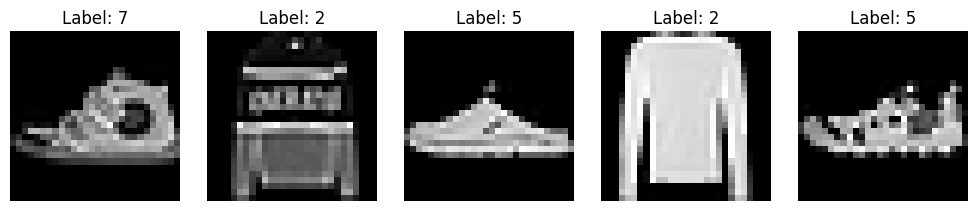

In [11]:
# Function to unnormalize images (since we normalized to [-1,1])
def unnormalize(img):
    return img * 0.5 + 0.5  # Reverse: (img * std) + mean

# Get a batch of training data
images, labels = next(iter(train_loader))

# Create grid
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(2, 5, i+1)
    img = unnormalize(images[i][0])  # Remove channel dim [1,28,28] -> [28,28]
    plt.imshow(img, cmap='gray')
    plt.title(f'Label: {labels[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()